<a href="https://colab.research.google.com/github/raffi326/mesin_learning/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Ahmad Raffi Muzacky

Nim  : A11.2023.15326


**Prediksi Penyakit Berdasarkan Gejala**

Diagnosis penyakit secara dini merupakan kunci utama dalam meningkatkan peluang keberhasilan pengobatan dan menekan angka mortalitas. Namun, banyak penyakit serius, seperti penyakit jantung, yang sering kali tidak menunjukkan gejala spesifik pada tahap awal, sehingga sulit terdeteksi tanpa pemeriksaan medis yang komprehensif. Penyakit jantung sendiri merupakan salah satu penyebab utama kematian di Indonesia dan dunia, menjadikannya fokus penting dalam inovasi teknologi kesehatan.

Kurangnya kesadaran masyarakat akan faktor risiko dan gejala awal, serta keterbatasan akses terhadap fasilitas diagnosis canggih, menjadi tantangan besar. Oleh karena itu, diperlukan sebuah sistem cerdas yang mampu menganalisis sekumpulan gejala dan faktor risiko untuk memberikan prediksi awal kemungkinan adanya suatu penyakit.


In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
johnsmith88_heart_disease_dataset_path = kagglehub.dataset_download('johnsmith88/heart-disease-dataset')

print('Data source import complete.')


Data source import complete.


# Business Problem

Penyakit jantung merupakan salah satu penyakit yang menyebabkan kematian tertinggi di Indonesia. Penyebab penyakit jantung sangat bervariasi, mulai dari hipertensi, gula darah yang tinggi, umur, dan lain-lain. Masih banyak masyarakat yang belum mengetahui gejala-gejala dari penyakit jantung ini. Oleh karena itu, pada analisa ini akan menentukan gejala apa saja yang berpengaruh terhadap penyakit jantung.

### Metrics


*   Key param : gejala-gejala awal
*   Key Activities : Melakukan diagnosis baik secara mandiri ataupun ke dokter
*   Key resources : dokter, pasien, internet



### Goals

Dapat menentukan gejala yang paling berpengaruh terhadap penyakit jantung

### Workflow
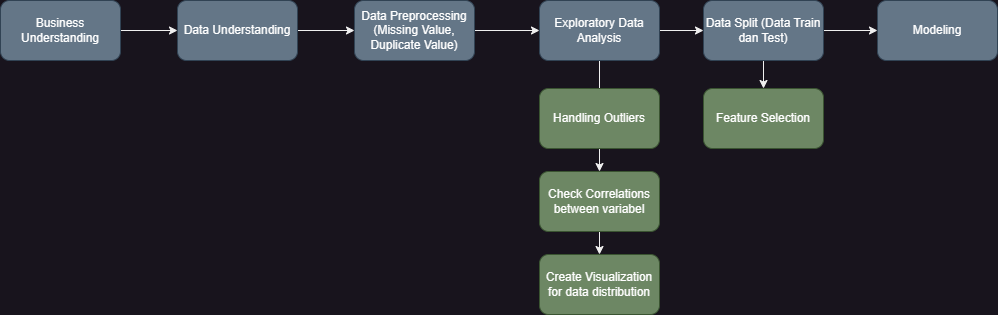

# Data Understanding

### Import Library

In [2]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import Dataset

In [3]:
#data location
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/heart-disease-dataset/heart.csv


### Read Data

In [5]:
path = '/kaggle/input/heart-disease-dataset/'

df = pd.read_csv(path +'heart.csv')

In [6]:
#melihat kolom yang terdapat pada dataset
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Penjelasan Variabel:
1. age : umur pasien
2. sex : (1 = Male; 0 = female)
3. cp  : Chest Pain (0=Asymptomatic; 1=atypical angina; 2 non-angina pain; 3=typical angina)
4. trestbps : Tekanan darah normal mm/hg
5. chol : Kadar kolestrol serum mm/dl
6. fps>120 mg/dl : fasting blood sugar (0=no; 1=yes)
7. restecg : (0=menunjukkan kemungkinan atau pasti hipertrofi ventrikel kiri; 1=normal;2=memiliki kelainan gelombang ST-T)
8. thalach : detak jantung maksimum
9. exang : Exercise Induced Angina (1=yes;0=no)
10. oldpeak : depresi ST yang disebabkan oleh olahraga relatif terhadap istirahat
11. slop : (0=downsloping; 1=flat; 2=upsloping)
12. ca : number of major vessels (0–3)
13. thal : (1=normal; 2=cacat tetap; 3=cacat reversibel)
14. target : (0= no disease; 1= disease)

In [7]:
#jumlah row dan column
df.shape

(1025, 14)

Terdapat 1025 row dan 14 column

In [8]:
#check data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
#check data statistik dari dataset
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
#check class
df['target'].value_counts().sort_index()

,count
target,
0,499
1,526


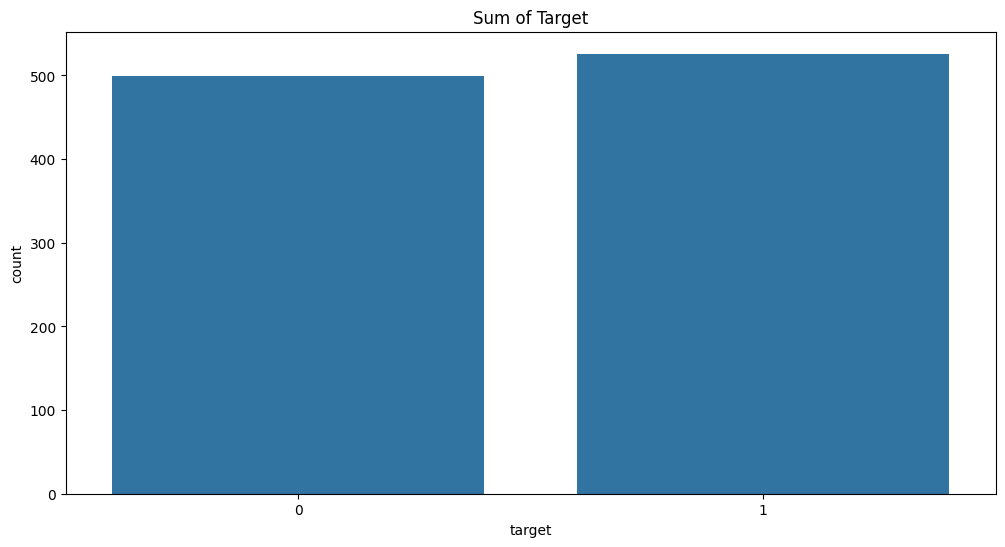

In [11]:
plt.figure(figsize=(12, 6))
#membuat ukuran kotaknya 12px dan 6px

sns.countplot(data=df, x='target')
plt.title('Sum of Target');

Dari gambar diatas dapat dilihat bahwa antara orang yang terdiagnosis terkena penyakit jantung lebih sedikit dibandingkan dengan yang tidak terdiagnosis (hanya berbeda 27 orang)

# Data Preprocessing

In [12]:
#mengecek missing values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [13]:
#check duplicate value
df.duplicated().sum()

np.int64(723)

Pada dataset ini, terdapat 723 nilai yang duplikat. Kita harus menghapusnya.

In [14]:
#drop duplicate value
df.drop_duplicates(inplace=True)

In [15]:
#check kembali apakah masih ada data yang duplikat
df.duplicated().sum()

np.int64(0)

In [16]:
#pengecekkan kembali jumlah baris dan kolom
df.shape

(302, 14)

Setelah dilakukan penghapusan terhadap data yang duplikat, maka sekarang dataset memiliki 302 baris dan 14 kolom.

# Exploratory Data Analysis

### Handling Outliers

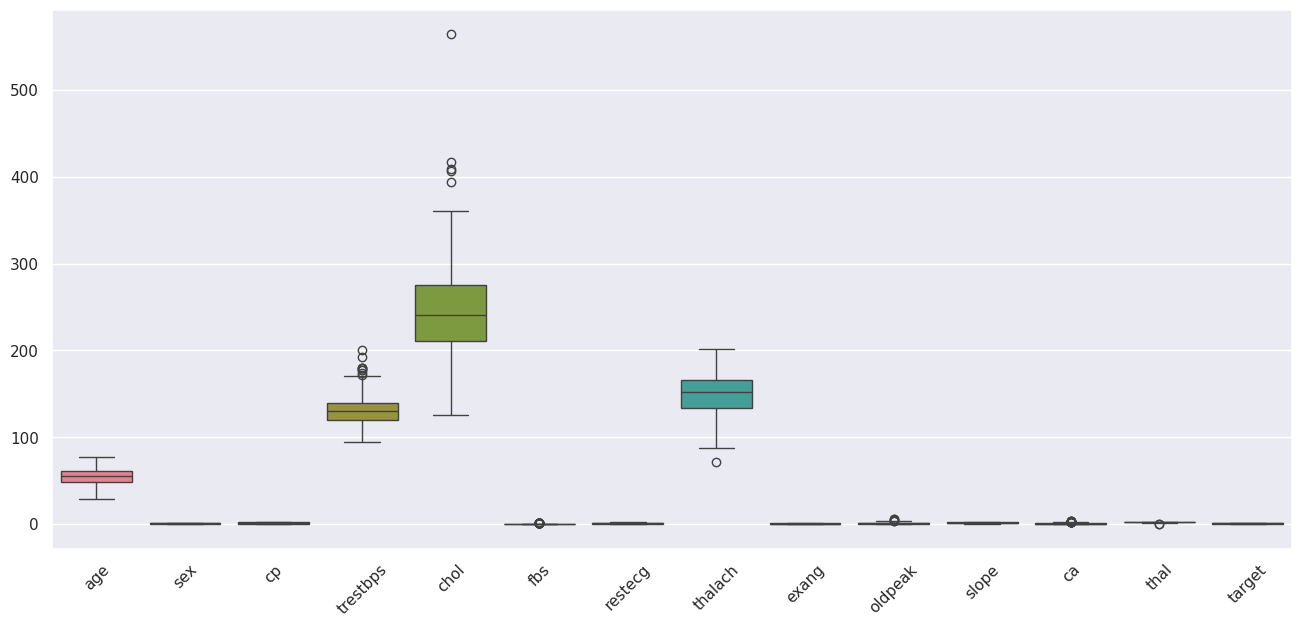

In [17]:
#check outliers
sns.set(style="darkgrid", palette="muted")
fig, ax = plt.subplots(figsize=(16,7))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

Dari visualisasi boxplot diatas, dapat dilihat bahwa terdapat outliers pada kolom trestbps, chol, dan thalach. oleh karena itu kita dapat menghapus outliers tersebut

In [18]:
#membagi kolom menjadi numerical dan categorical features
cat = df.select_dtypes(include='object').columns
num = list(df[['trestbps', 'chol', 'thalach']].columns)
#num.remove('target')

In [19]:
#rumus untuk menghitung dan menghapus outlier
for cols in num:
    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)
    IQR=Q3-Q1
    lr= Q1-(1.5 * IQR)
    ur= Q3+(1.5 * IQR)
    df[cols] = df[cols].mask(df[cols]<lr, lr, )
    df[cols] = df[cols].mask(df[cols]>ur, ur, )

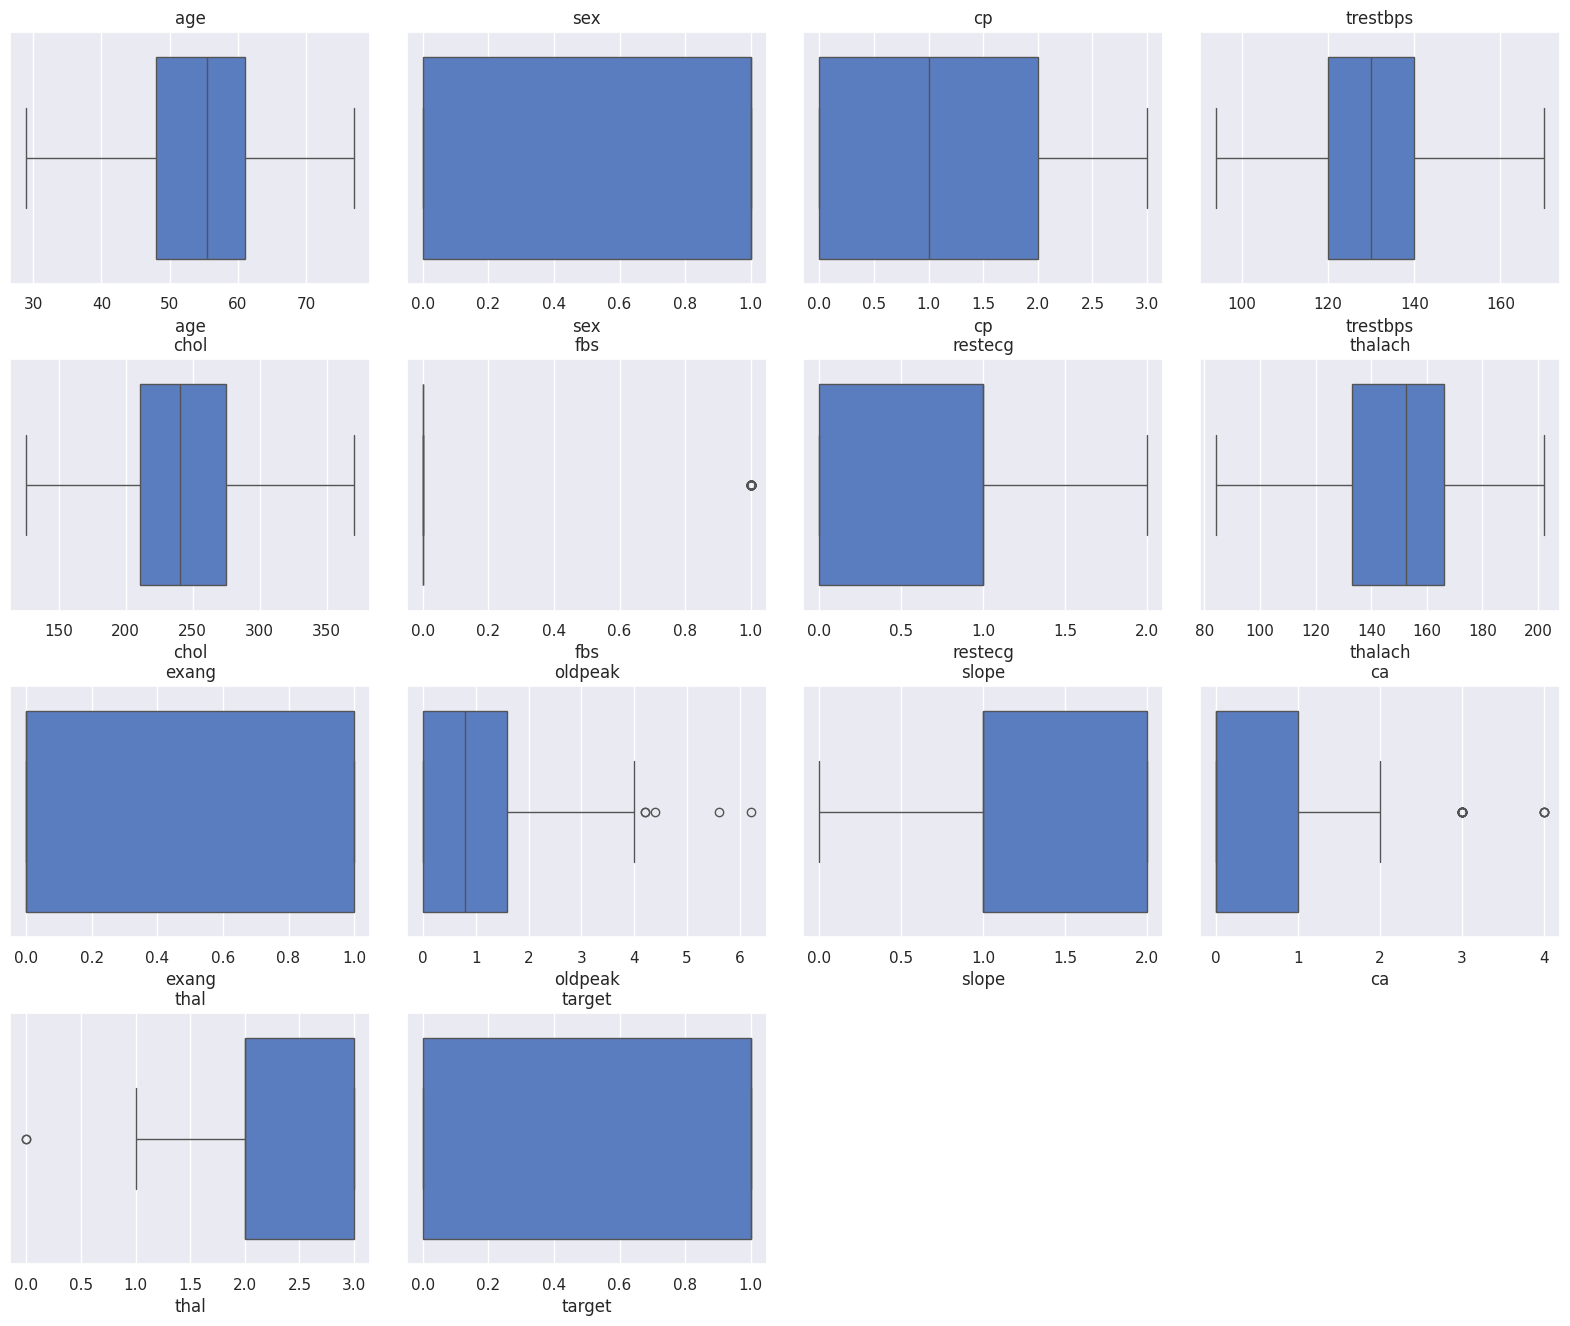

In [20]:
#check kembali outliers
plt.figure(figsize=(20, 16))

# desc
a = 4
b = 4
c = 1

columns = df.columns

for col in columns:
    plt.subplot(a, b, c)
    sns.boxplot(data=df, x=col)
    plt.title(f'{col}')
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    c += 1

### Melihat Korelasi Antarvariabel dan Class

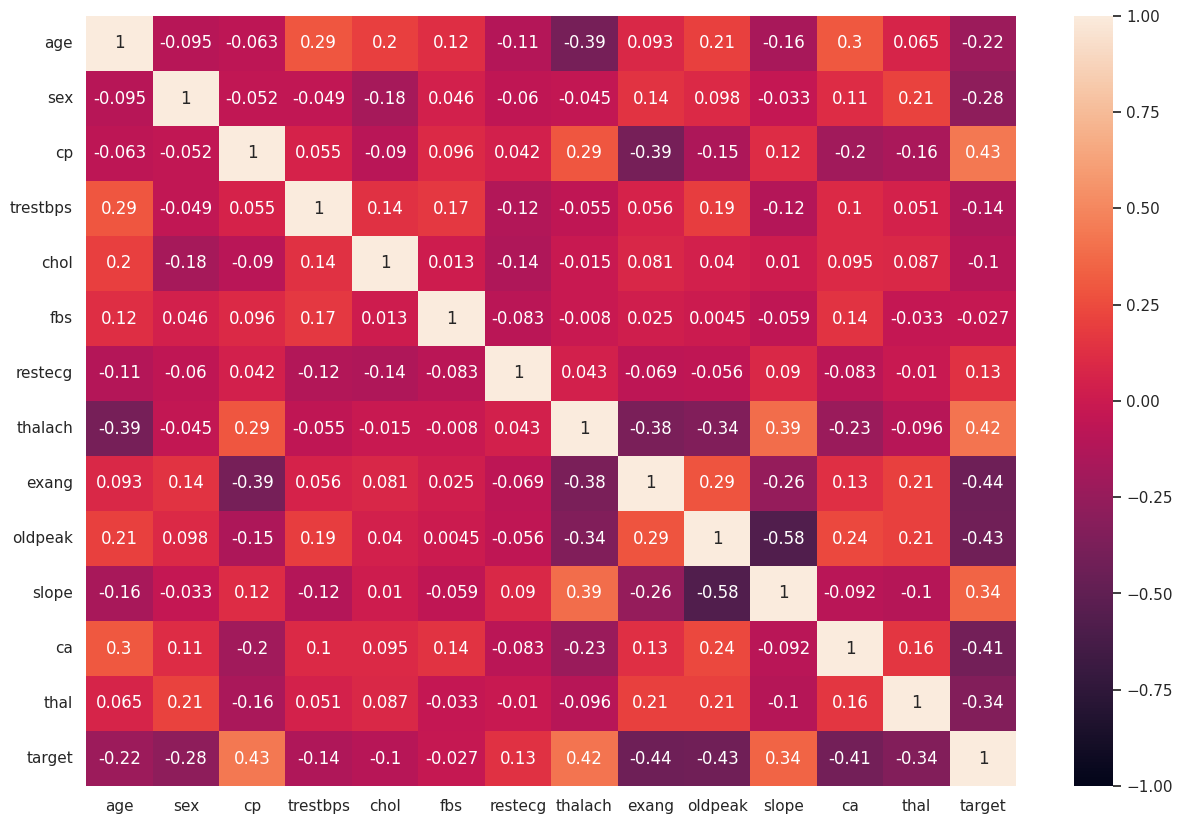

In [21]:
#check data korelasinya
correlation = df.corr()
fig, ax = plt.subplots(figsize=(15,10))
ax = sns.heatmap(correlation, vmax=1, vmin=-1, annot=True)

# show it
plt.show()

Dari heatmap diatas dapat dilihat bahwa terdapat korelasi positif antara target dan cp (0.43), target dan thalach (0.42), thalach dan slope (0.39)

<Figure size 640x480 with 0 Axes>

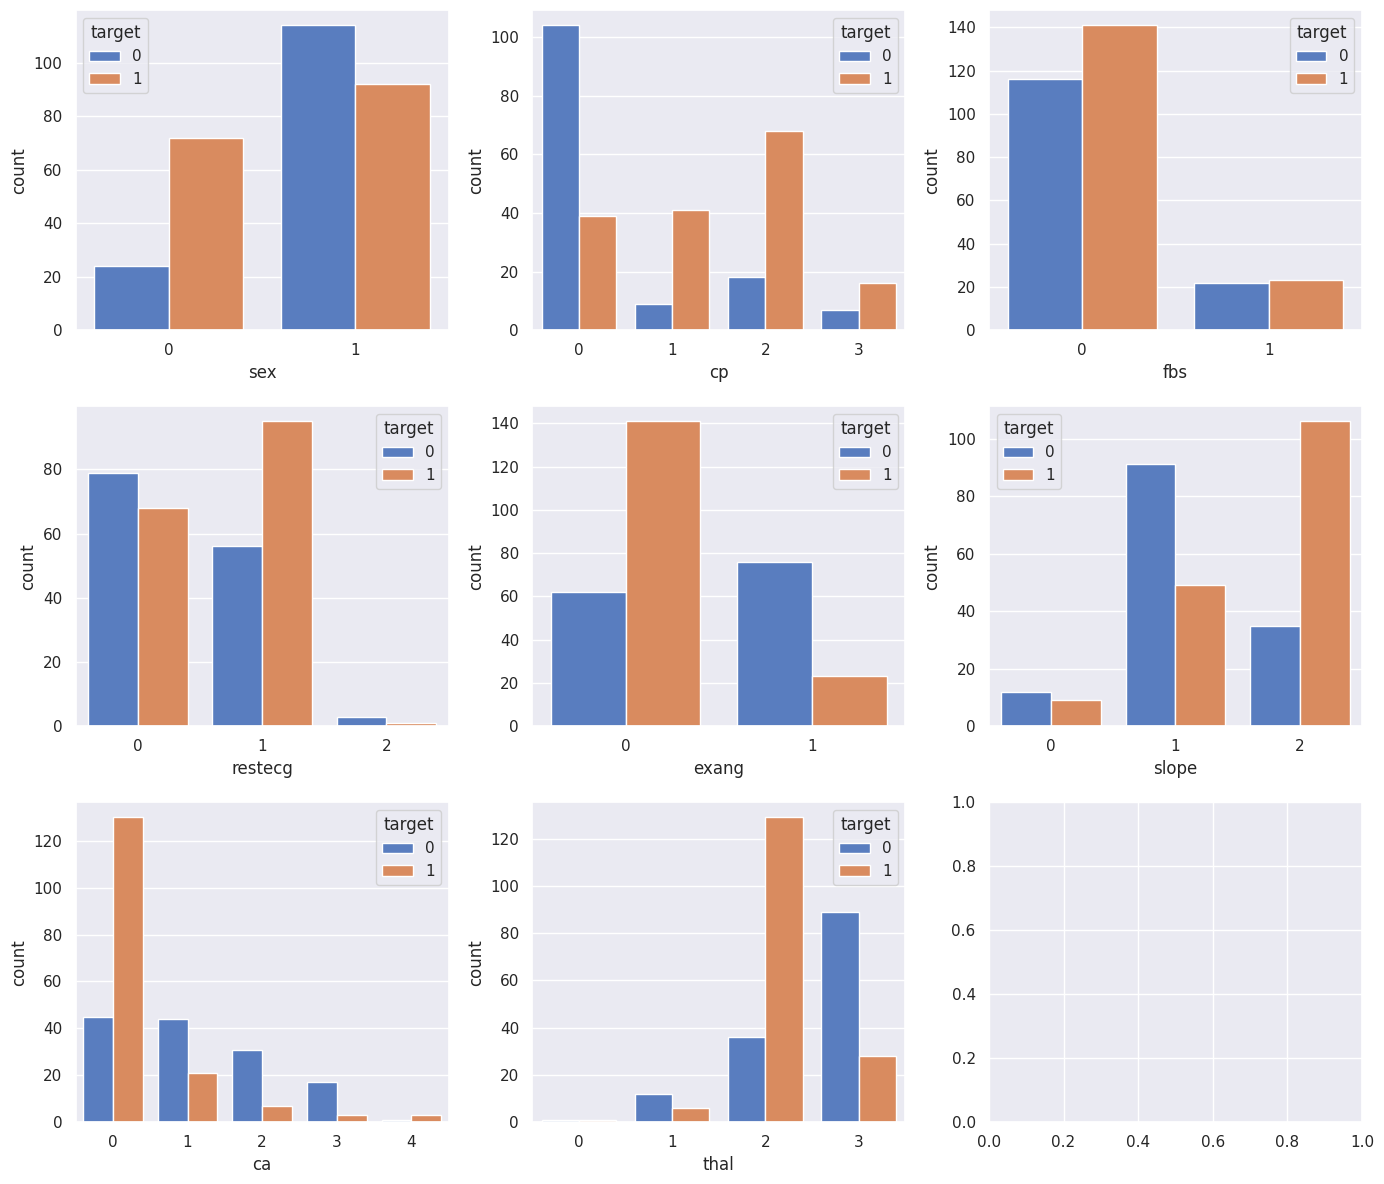

In [22]:
#melihat hubungan antar variabel dan class
fig = plt.figure()
fig,ax = plt.subplots(3,3, figsize = (14,12))
sns.countplot(data=df, x = 'sex', hue = 'target', ax=ax[0][0])
sns.countplot(data=df, x = 'cp', hue = 'target', ax=ax[0][1])
sns.countplot(data=df, x = 'fbs', hue = 'target', ax=ax[0][2])
sns.countplot(data=df, x = 'restecg', hue = 'target', ax=ax[1][0])
sns.countplot(data=df, x = 'exang', hue = 'target', ax=ax[1][1])
sns.countplot(data=df, x = 'slope', hue = 'target', ax=ax[1][2])
sns.countplot(data=df, x = 'ca', hue = 'target', ax=ax[2][0])
sns.countplot(data=df, x = 'thal', hue = 'target', ax=ax[2][1])
plt.tight_layout()
plt.show()

Visualisasi di atas merupakan hubungan antara target dan feature. Dapat dilihat bahwa pada gender, perempuan lebih sedikit yang terdiagnosis penyakit jantung dibandingkan yang tidak terdiagnosis penyakit jantung, sedangkan laki-laki lebih banyak yang terdiagnosis penyakit jantung. Kemudian pada kolom cp (Chest Pain) dapat dilihat bahwa yang memiliki jenis nyeri dada asymptomatic (atau dilambangkan dengan 0) terdeteksi lebih banyak yang terdiagnosis penyakit jantung dibandingkan jenis nyeri dada lainnya (1,2, dan 3) dan seterusnya. (Kolom age, trestbps, chol, thalach dan oldpeak tidak dimasukkan karena memiliki data yang beragam.)

### Melihat Distribusi Data

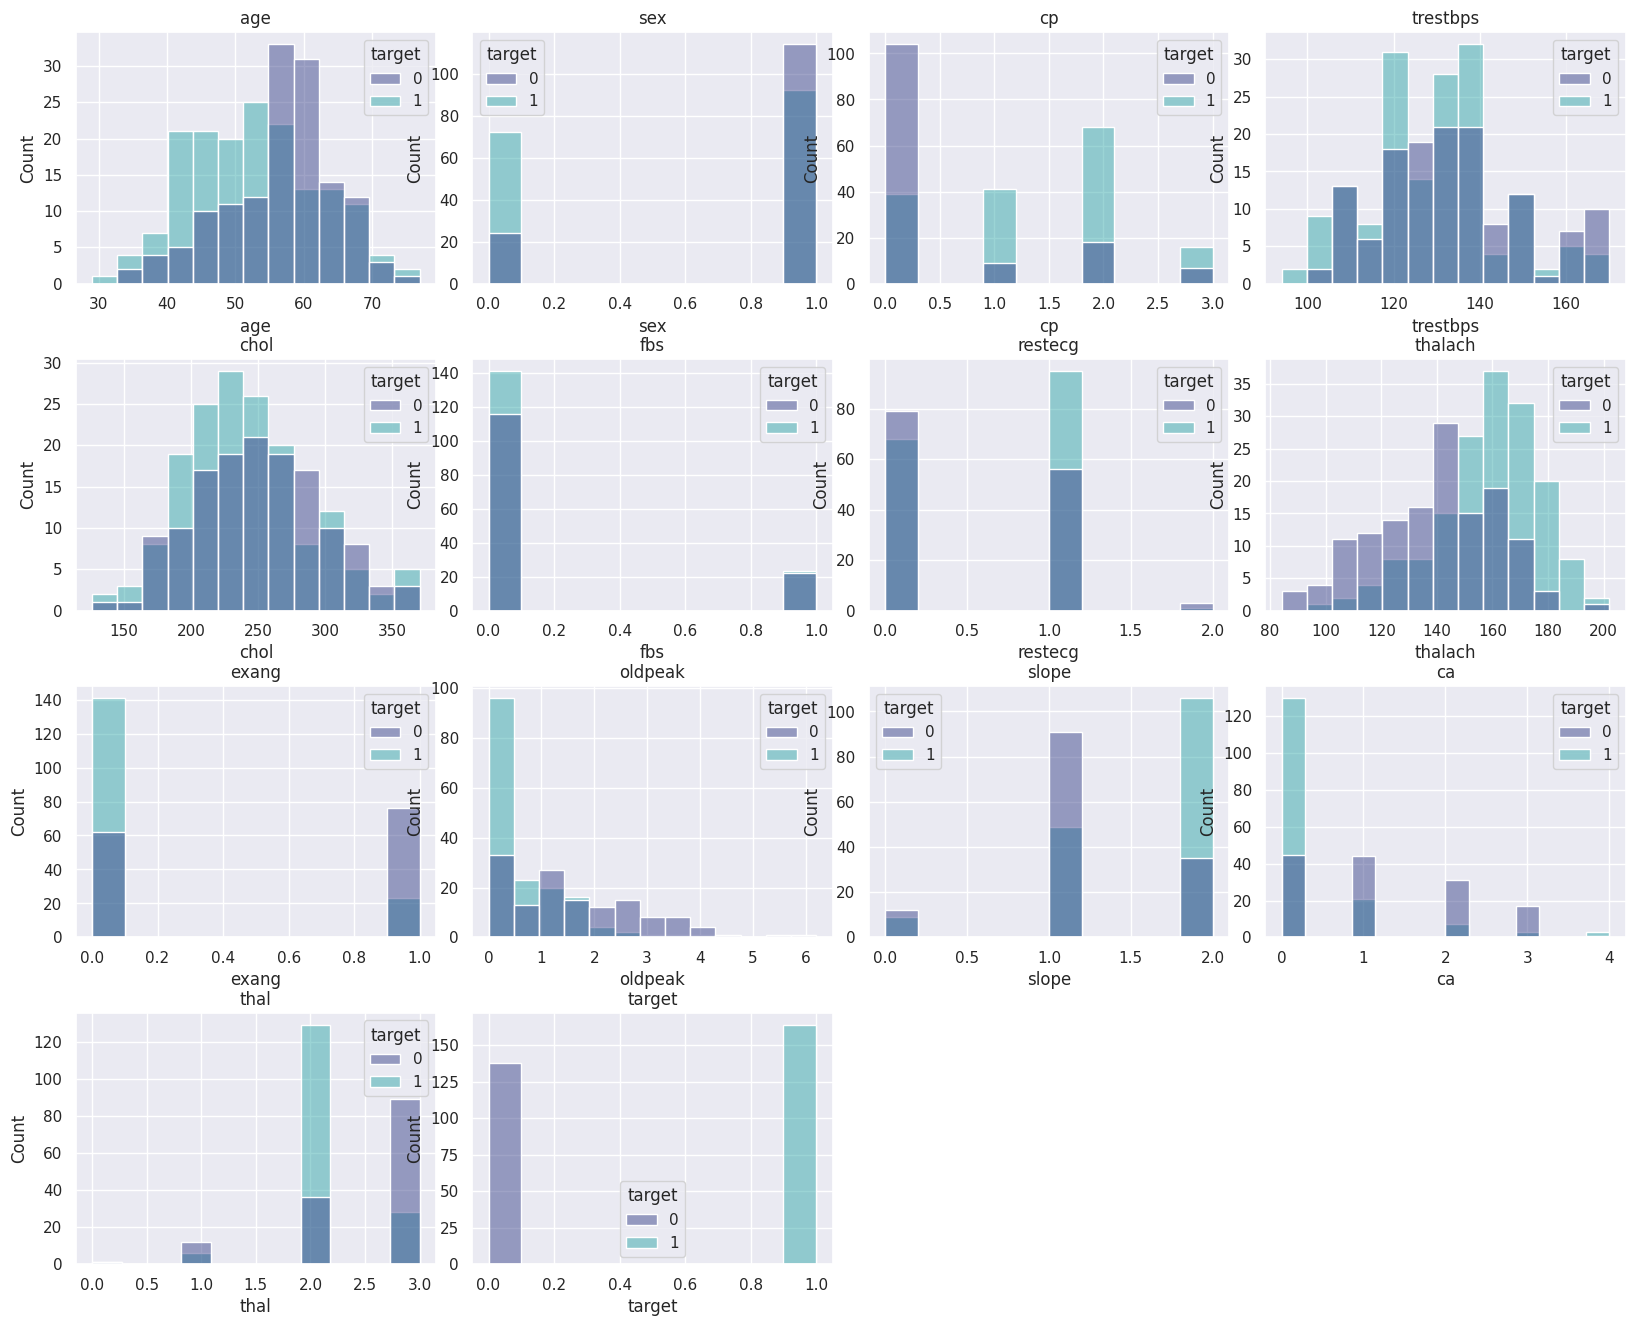

In [23]:
#melihat distribusi data antarvariabel dan class
plt.figure(figsize=(20, 16))

# desc
a = 4  # number of rows
b = 4  # number of columns
c = 1  # initialize plot counter

columns = df.columns
target = df['target']

for col in columns:
    plt.subplot(a, b, c)
    sns.histplot(data=df, x=col, hue="target", palette="mako")
    plt.title(f'{col}')
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    c += 1

Dari visualisasi di atas kita dapat melihat distribusi datanya dan jumlah orang yang terdiagnosis terkena penyakit jantung atau tidak.

# Scaling Data

In [24]:
#memisahkan variabel menjadi X (dependen variabel) dan y(independen variabel)
# independent variable or features
features = df.drop(['target'],axis=1)

# dependent variable or class/target
target = df['target']
X = features
y = target

#import preprocessing dan standardscaler untuk melakukan scalling
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

#membuat scaler object dan fit data yg ingin distandarisasi/normalisasi
scaler = StandardScaler()
scaler.fit(X)

#transform kedalam variabel baru
x_scaled = scaler.transform(X)

# Hypothesis

"Apakah Terdapat hubungan antara faktor risiko seperti usia, jenis kelamin, tekanan darah, kadar kolesterol, dan riwayat keluarga dengan kejadian penyakit jantung?. Dengan menggunakan model klasifikasi yang sesuai, dapat diprediksi dengan akurasi yang signifikan apakah seseorang akan terkena penyakit jantung atau tidak berdasarkan faktor-faktor risiko tersebut."

# Cross Validation

### Melihat Akurasi dengan Cross Validation untuk model Decision Tree

In [25]:
# Now let's use 5-fold cross-validation to evaluate the model performance
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier
# Create a Decision Tree Classifier model
model = DecisionTreeClassifier()

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.2, random_state = 42)

scores = cross_val_score(model, X, y, cv=5)
print("Accuracy with cross-validation: %.2f with standard deviation %.2f" % (scores.mean(), scores.std()))

Accuracy with cross-validation: 0.78 with standard deviation 0.04


### Melihat Akurasi dengan Cross Validation untuk model Random Forest

In [26]:
# Now let's use 5-fold cross-validation to evaluate the model performance
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
# Create a Random Forest Classifier model
model = RandomForestClassifier()

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.2, random_state = 42)

scores = cross_val_score(model, X, y, cv=5)
print("Accuracy with cross-validation: %.2f with standard deviation %.2f" % (scores.mean(), scores.std()))

Accuracy with cross-validation: 0.83 with standard deviation 0.06


### Melihat Akurasi dengan Cross Validation Untuk Model Logistic Regression

In [27]:
# Now let's use 5-fold cross-validation to evaluate the model performance
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model
model = LogisticRegression()

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.2, random_state = 42)

scores = cross_val_score(model, X, y, cv=5)
print("Accuracy with cross-validation: %.2f with standard deviation %.2f" % (scores.mean(), scores.std()))

Accuracy with cross-validation: 0.84 with standard deviation 0.05


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

# Modeling

### Melakukan Modeling dengan Menggunakan Decision Tree

In [28]:
#melihat akurasi dengan menggunakan decision tree
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

classification_DT = DecisionTreeClassifier()
classification_DT = classification_DT.fit(X_train, y_train)
y_pred_DT = classification_DT.predict(X_test)
acc_DT = accuracy_score(y_test, y_pred_DT)
print("The accuracy of Decision Tree models is ", acc_DT*100, "%")

The accuracy of Decision Tree models is  73.77049180327869 %


In [29]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print("Classification Report:")
print(classification_report(y_test, y_pred_DT))

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.81      0.76        32
           1       0.76      0.66      0.70        29

    accuracy                           0.74        61
   macro avg       0.74      0.73      0.73        61
weighted avg       0.74      0.74      0.74        61



Dengan menggunakan model decision tree, nilai akurasi adalah 70%

### Menggunakan Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

classification_RF = RandomForestClassifier()
classification_RF = classification_RF.fit(X_train, y_train)
y_pred_RF = classification_RF.predict(X_test)
acc_RF = accuracy_score(y_test, y_pred_RF)
print("The accuracy of Random Forest models is ", acc_RF*100, "%")

The accuracy of Random Forest models is  81.9672131147541 %


In [31]:
print("Classification Report:")
print(classification_report(y_test, y_pred_RF))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.83        32
           1       0.80      0.83      0.81        29

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



Dengan menggunakan model Random Forest, didapatkan akurasi bernilai 89%

### Menggunakan Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
log_clf = LogisticRegression(max_iter=1000, penalty='l2', solver='liblinear', C=0.05, random_state = 4)
log_clf.fit(X_train, y_train)
log_score = metrics.f1_score(y_test, log_clf.predict(X_test))
print("The accuracy of Logistic Regression is ", log_score*100, "%")

The accuracy of Logistic Regression is  83.07692307692308 %


Dengan menggunakan Logistic Regression, didapatkan akurasi bernilai 83%

# Feature Importance

Model Random Forest terlatih untuk menghitung seberapa penting fitur-fitur yang terdapat pada dataset heart disease ini

In [33]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=3,
                             max_depth=5,
                             random_state=42)

Text(0.5, 1.0, 'Feature Importances')

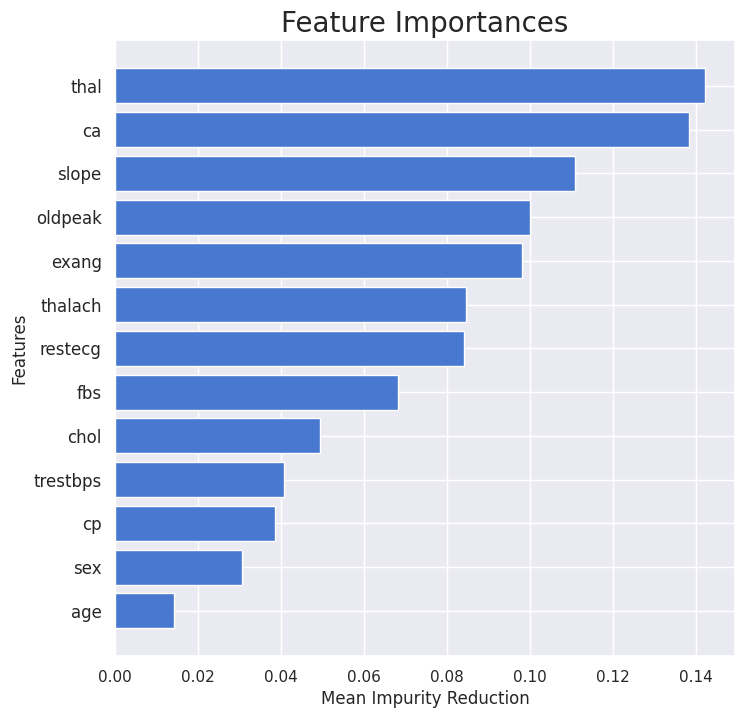

In [34]:
classifier = RandomForestClassifier()
classifier.fit(X_train,y_train)

tree_feature =  pd.Series(classifier.feature_importances_, X.columns).sort_values(ascending = True)
plt.figure(figsize = (8,8))
plt.barh(X.columns, tree_feature)
plt.xlabel('Mean Impurity Reduction', fontsize = 12)
plt.ylabel('Features', fontsize = 12)
plt.yticks(fontsize = 12)
plt.title('Feature Importances', fontsize = 20)

Dari visualisasi di atas, dapat dilihat bahwa dengan mengacu pada model Random Forest Classifier, Fitur yang memiliki kontribusi besar pada prediksi Heart Disease ini adalah thal. Jadi dapat kita prediksikan bahwa thalach (detak jantung maksimum) dapat menjadi gejala yang penting untuk diperhatikan oleh orang yang beresiko terdeteksi penyakit jantung.

# Hyperparameter Tuning

In [36]:
from sklearn.model_selection import GridSearchCV

clf_model = RandomForestClassifier()

param_grid = {
    'n_estimators': [400, 700, 1000],
    'max_depth': [15,20,25],
    'max_leaf_nodes': [50, 100, 200]
}

gs = GridSearchCV(
        estimator=clf_model,
        param_grid=param_grid,
        cv=10,
        n_jobs=-1,
        scoring='roc_auc',
        verbose=2
    )

fitted_clf_model = gs.fit(X_train, y_train)

Fitting 10 folds for each of 27 candidates, totalling 270 fits


In [37]:
#melihat Best parameter dan score dari fitted_clf
print('Best parameters:', fitted_clf_model.best_params_)
print('Best score:', fitted_clf_model.best_score_)

Best parameters: {'max_depth': 15, 'max_leaf_nodes': 200, 'n_estimators': 400}
Best score: 0.9064010989010989


In [38]:
#melihat score
fitted_clf_model.score(X_test, y_test)

np.float64(0.8890086206896551)

In [39]:
#Melihat perbandingan dari hasil yang aktual dan prediksi
fitted_model_preds = fitted_clf_model.predict(X_test)
plot_compare = pd.DataFrame({'Actual':y_test, 'Predicted':fitted_model_preds})
plot_compare

,Actual,Predicted
245,1,1
349,0,1
135,0,0
389,1,0
66,1,1
...,...,...
402,1,1
123,1,1
739,0,0
274,1,0


## ROC Analysis

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

# Initialize the models
logreg = LogisticRegression()
rf = RandomForestClassifier()
dt = DecisionTreeClassifier()

# Train the models
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
logreg.fit(X_train, y_train)

# Predict the probabilities for the positive class
y_pred_dt = dt.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict_proba(X_test)[:, 1]
y_pred_logreg = logreg.predict_proba(X_test)[:, 1]

# Calculate the AUC-ROC scores
auc_dt = roc_auc_score(y_test, y_pred_dt)
auc_rf = roc_auc_score(y_test, y_pred_rf)
auc_logreg = roc_auc_score(y_test, y_pred_logreg)

print(f"AUC-ROC for Decision Tree: {auc_dt}")
print(f"AUC-ROC for Random Forest: {auc_rf}")
print(f"AUC-ROC for Logistic Regression: {auc_logreg}")

AUC-ROC for Decision Tree: 0.802801724137931
AUC-ROC for Random Forest: 0.890625
AUC-ROC for Logistic Regression: 0.8394396551724138


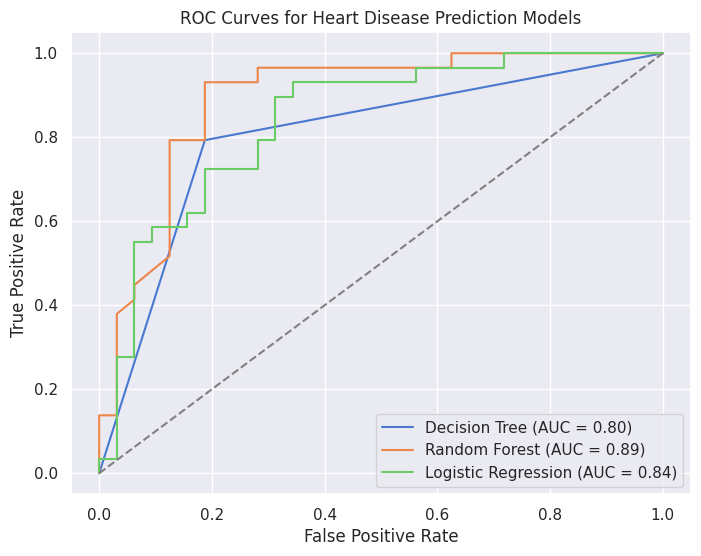

In [41]:
#membuat plot roc setiap model
def plot_roc_curves(y_test, y_pred_logreg, y_pred_rf, y_pred_svc):
    plt.figure(figsize=(8, 6))

    # Calculate ROC curves for each model
    fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
    fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_logreg)

    # Plot ROC curves
    plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
    plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {auc_logreg:.2f})')

    # Plot random classifier
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

    # Format the plot
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Heart Disease Prediction Models')
    plt.legend()
    plt.show()

plot_roc_curves(y_test, y_pred_logreg, y_pred_rf, y_pred_dt)

Dari ROC Curve di atas dan hypertuning yang telah dilakukan dan dibandingkan dari data test pada dataset heart disease ini, dapat disimpulkan bahwa performa model terbaik terdapat pada model Random Forest dengan nilai 89%